**G05:** Jakober, Matzinger, Winkler, Salzmann

In [1]:
import itertools
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from torch import nn
from torch.utils.data import DataLoader
from torchsummary import summary
from torchvision import datasets, transforms
from tqdm import tqdm

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device is set to: {device}")

Device is set to: cuda


In [3]:
torch.manual_seed(42000)

# Loading the Data

In [4]:
batch_size = 1024

training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

loader = DataLoader(training_data, batch_size=60000, shuffle=True, num_workers=2)
X, _ = next(iter(loader))
mean, std = torch.mean(X).item(), torch.std(X).item()
print(f"Before normalization: Mean: {mean:.4f}, Std: {std:.4f}")

training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
)

train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Testing the normalization
X, _ = next(iter(train_loader))
print(f"After normalization: Mean: {torch.mean(X):.4f}, Std: {torch.std(X):.4f}")

Before normalization: Mean: 0.4734, Std: 0.2516
After normalization: Mean: 0.0154, Std: 1.0068


# Defining CNN

In [5]:
class CNN(nn.Module):
    def __init__(self, activation_function = F.relu, use_batch_norm = False, use_dropout = False):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.batch_norm2 = nn.BatchNorm2d(32)
        self.max_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.batch_norm3 = nn.BatchNorm2d(64)
        self.max_pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(in_features=4*4*64, out_features=512)
        self.batch_norm4 = nn.BatchNorm1d(512)
        self.linear2 = nn.Linear(in_features=512, out_features=128)
        self.batch_norm5 = nn.BatchNorm1d(128)
        self.linear3 = nn.Linear(in_features=128, out_features=10)

        self.dropout = nn.Dropout(0.2)
        self.activation_function = activation_function
        self.use_batch_norm = use_batch_norm
        self.use_dropout = use_dropout

    def forward(self, x):
        x = self.conv1(x)
        if self.use_batch_norm:
            x = self.batch_norm1(x)
        x = self.max_pool1(self.activation_function(x))

        x = self.conv2(x)
        if self.use_batch_norm:
            x = self.batch_norm2(x)
        x = self.max_pool2(self.activation_function(x))

        x = self.conv3(x)
        if self.use_batch_norm:
            x = self.batch_norm3(x)
        x = self.max_pool3(self.activation_function(x))

        x = self.flatten(x)

        if self.use_dropout:
            x = self.dropout(x)
        x = self.linear1(x)
        if self.use_batch_norm:
            x = self.batch_norm4(x)
        x = self.activation_function(x)

        if self.use_dropout:
            x = self.dropout(x)
        x = self.linear2(x)
        if self.use_batch_norm:
            x = self.batch_norm5(x)
        x = self.activation_function(x)

        if self.use_dropout:
            x = self.dropout(x)
        x = self.linear3(x)

        return x

In [6]:
model = CNN().to(device)
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         MaxPool2d-2           [-1, 32, 16, 16]               0
            Conv2d-3           [-1, 32, 16, 16]           9,248
         MaxPool2d-4             [-1, 32, 8, 8]               0
            Conv2d-5             [-1, 64, 8, 8]          18,496
         MaxPool2d-6             [-1, 64, 4, 4]               0
           Flatten-7                 [-1, 1024]               0
            Linear-8                  [-1, 512]         524,800
            Linear-9                  [-1, 128]          65,664
           Linear-10                   [-1, 10]           1,290
Total params: 620,394
Trainable params: 620,394
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.44
Params size (MB): 2.37
Estimated T

# Training Loop

In [7]:
def run_epoch(model, dataloader, optimizer, criterion, train=True):
    """
    Runs one epoch for training or validation.
    """
    epoch_loss = 0
    correct = 0
    total_samples = len(dataloader.dataset)

    if train:
        model.train()
    else:
        model.eval()

    for X, y in tqdm(dataloader, desc=f'{"Train" if train else "Val"} Epoch', disable=True):
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output = model(X)
            loss = criterion(output, y)

        epoch_loss += loss.item()
        _, y_pred = torch.max(output, dim=1)
        correct += torch.sum(y_pred == y).item()

        if train:
            loss.backward()
            optimizer.step()

    avg_loss = epoch_loss / len(dataloader)
    accuracy = correct / total_samples

    return avg_loss, accuracy

def trainer(model, train_loader, val_loader, optimizer, criterion, n_epochs):
    """
    Trains and evaluates the model for n_epochs.
    """
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_accs = []
    epoch_val_accs = []

    for epoch in range(n_epochs):

        print(f'\nEpoch {epoch+1}/{n_epochs}')
        print('----------')

        train_loss, train_acc = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer, criterion, train=False)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_train_accs.append(train_acc)
        epoch_val_accs.append(val_acc)

        print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}\nVal Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}')

    return epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs

In [8]:
num_epochs = 20
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs)


Epoch 1/20
----------
Train Loss: 1.8518, Train Accuracy: 0.3302
Val Loss: 1.5699, Val Accuracy: 0.4291

Epoch 2/20
----------
Train Loss: 1.5108, Train Accuracy: 0.4515
Val Loss: 1.4278, Val Accuracy: 0.4840

Epoch 3/20
----------
Train Loss: 1.3743, Train Accuracy: 0.5039
Val Loss: 1.3308, Val Accuracy: 0.5208

Epoch 4/20
----------
Train Loss: 1.2904, Train Accuracy: 0.5372
Val Loss: 1.2470, Val Accuracy: 0.5605

Epoch 5/20
----------
Train Loss: 1.2034, Train Accuracy: 0.5717
Val Loss: 1.1889, Val Accuracy: 0.5742

Epoch 6/20
----------
Train Loss: 1.1355, Train Accuracy: 0.5979
Val Loss: 1.1188, Val Accuracy: 0.6021

Epoch 7/20
----------
Train Loss: 1.0870, Train Accuracy: 0.6167
Val Loss: 1.0829, Val Accuracy: 0.6162

Epoch 8/20
----------
Train Loss: 1.0189, Train Accuracy: 0.6423
Val Loss: 1.0438, Val Accuracy: 0.6289

Epoch 9/20
----------
Train Loss: 0.9650, Train Accuracy: 0.6595
Val Loss: 0.9896, Val Accuracy: 0.6452

Epoch 10/20
----------
Train Loss: 0.9206, Train Accur

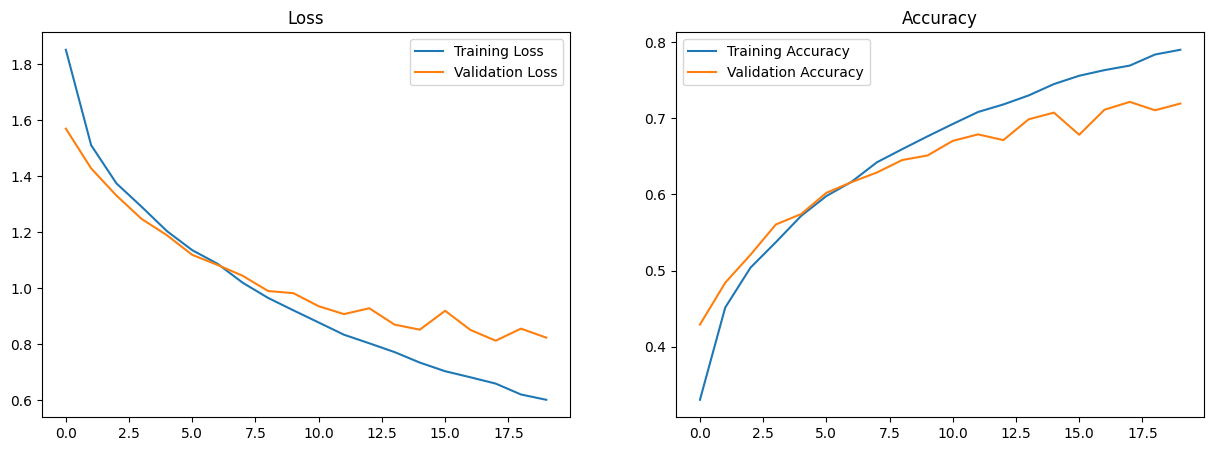

In [9]:
plt.figure(1, figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_train_losses, label='Training Loss')
plt.plot(epoch_val_losses, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epoch_train_accs, label='Training Accuracy')
plt.plot(epoch_val_accs, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

## Tanh instead of ReLU

In [10]:
num_epochs = 20

model_tanh = CNN(F.tanh).to(device)

optimizer = torch.optim.Adam(model_tanh.parameters())
criterion = nn.CrossEntropyLoss()

epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs = trainer(model_tanh, train_loader, test_loader, optimizer, criterion, num_epochs)


Epoch 1/20
----------
Train Loss: 1.7235, Train Accuracy: 0.3750
Val Loss: 1.4372, Val Accuracy: 0.4860

Epoch 2/20
----------
Train Loss: 1.3281, Train Accuracy: 0.5220
Val Loss: 1.2300, Val Accuracy: 0.5578

Epoch 3/20
----------
Train Loss: 1.1574, Train Accuracy: 0.5874
Val Loss: 1.0967, Val Accuracy: 0.6128

Epoch 4/20
----------
Train Loss: 1.0323, Train Accuracy: 0.6352
Val Loss: 1.0281, Val Accuracy: 0.6353

Epoch 5/20
----------
Train Loss: 0.9441, Train Accuracy: 0.6666
Val Loss: 0.9611, Val Accuracy: 0.6579

Epoch 6/20
----------
Train Loss: 0.8752, Train Accuracy: 0.6940
Val Loss: 0.9244, Val Accuracy: 0.6764

Epoch 7/20
----------
Train Loss: 0.8232, Train Accuracy: 0.7113
Val Loss: 0.8979, Val Accuracy: 0.6882

Epoch 8/20
----------
Train Loss: 0.7656, Train Accuracy: 0.7332
Val Loss: 0.8542, Val Accuracy: 0.7057

Epoch 9/20
----------
Train Loss: 0.7279, Train Accuracy: 0.7469
Val Loss: 0.8656, Val Accuracy: 0.7028

Epoch 10/20
----------
Train Loss: 0.6806, Train Accur

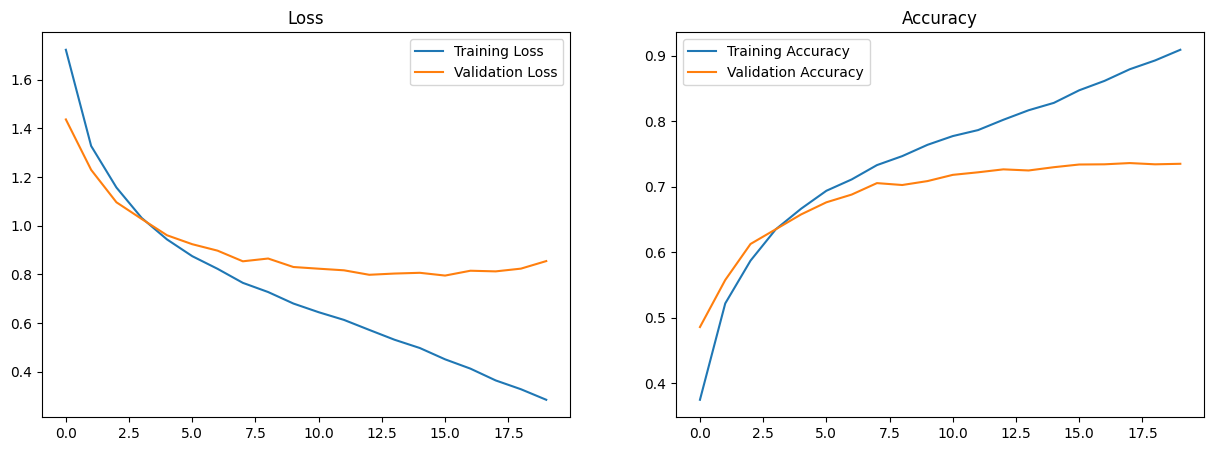

In [11]:
plt.figure(1, figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_train_losses, label='Training Loss')
plt.plot(epoch_val_losses, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epoch_train_accs, label='Training Accuracy')
plt.plot(epoch_val_accs, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

## With Batchnorm


Epoch 1/20
----------
Train Loss: 1.3509, Train Accuracy: 0.5267
Val Loss: 1.1495, Val Accuracy: 0.5950

Epoch 2/20
----------
Train Loss: 0.9006, Train Accuracy: 0.6853
Val Loss: 0.9417, Val Accuracy: 0.6684

Epoch 3/20
----------
Train Loss: 0.7106, Train Accuracy: 0.7543
Val Loss: 0.8796, Val Accuracy: 0.6904

Epoch 4/20
----------
Train Loss: 0.5744, Train Accuracy: 0.8036
Val Loss: 0.8981, Val Accuracy: 0.6958

Epoch 5/20
----------
Train Loss: 0.4517, Train Accuracy: 0.8486
Val Loss: 0.9566, Val Accuracy: 0.6902

Epoch 6/20
----------
Train Loss: 0.3441, Train Accuracy: 0.8884
Val Loss: 0.9354, Val Accuracy: 0.7027

Epoch 7/20
----------
Train Loss: 0.2513, Train Accuracy: 0.9206
Val Loss: 0.8915, Val Accuracy: 0.7288

Epoch 8/20
----------
Train Loss: 0.1757, Train Accuracy: 0.9487
Val Loss: 0.9371, Val Accuracy: 0.7259

Epoch 9/20
----------
Train Loss: 0.1241, Train Accuracy: 0.9653
Val Loss: 1.0557, Val Accuracy: 0.7156

Epoch 10/20
----------
Train Loss: 0.0837, Train Accur

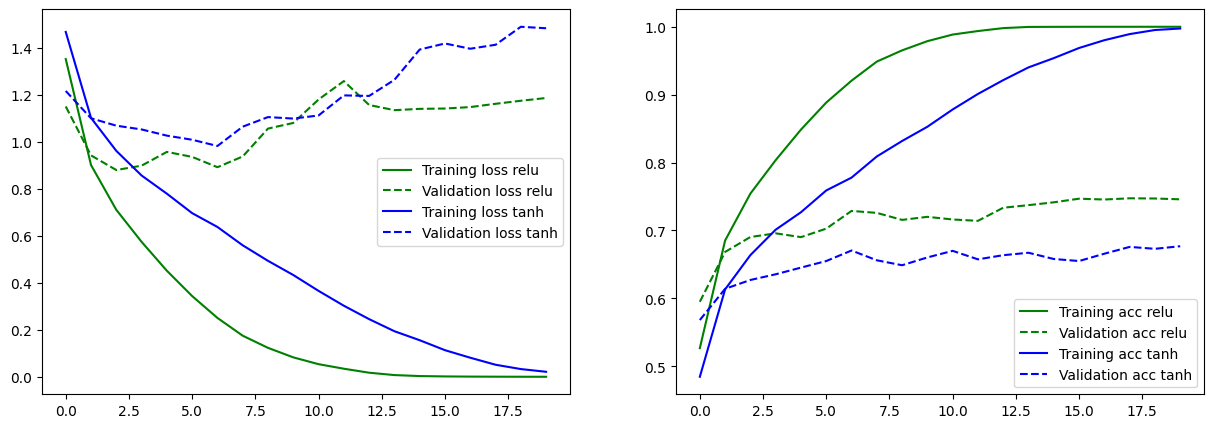

In [12]:
num_epochs = 20
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, act_func in enumerate([F.relu, F.tanh]):
    model_bn = CNN(act_func, use_batch_norm = True).to(device)

    optimizer = torch.optim.Adam(model_bn.parameters())

    epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs = trainer(model_bn, train_loader, test_loader, optimizer, criterion, num_epochs)

    axes[0].plot(epoch_train_losses, linestyle='-', color='g' if i == 0 else 'b', label=f'Training loss {act_func.__name__}')
    axes[0].plot(epoch_val_losses, linestyle='--', color='g' if i == 0 else 'b', label=f'Validation loss {act_func.__name__}')
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(epoch_train_accs, linestyle='-', color='g' if i == 0 else 'b', label=f'Training acc {act_func.__name__}')
    axes[1].plot(epoch_val_accs, linestyle='--', color='g' if i == 0 else 'b', label=f'Validation acc {act_func.__name__}')
    axes[1].legend()
    axes[1].grid()

plt.show()

# With Regularisation


Epoch 1/20
----------
Train Loss: 1.4816, Train Accuracy: 0.4771
Val Loss: 1.2830, Val Accuracy: 0.5353

Epoch 2/20
----------
Train Loss: 1.0654, Train Accuracy: 0.6254
Val Loss: 0.9360, Val Accuracy: 0.6643

Epoch 3/20
----------
Train Loss: 0.9149, Train Accuracy: 0.6782
Val Loss: 0.8835, Val Accuracy: 0.6877

Epoch 4/20
----------
Train Loss: 0.8221, Train Accuracy: 0.7138
Val Loss: 0.7775, Val Accuracy: 0.7272

Epoch 5/20
----------
Train Loss: 0.7512, Train Accuracy: 0.7353
Val Loss: 0.7562, Val Accuracy: 0.7358

Epoch 6/20
----------
Train Loss: 0.6996, Train Accuracy: 0.7543
Val Loss: 0.7328, Val Accuracy: 0.7443

Epoch 7/20
----------
Train Loss: 0.6542, Train Accuracy: 0.7701
Val Loss: 0.7074, Val Accuracy: 0.7538

Epoch 8/20
----------
Train Loss: 0.6079, Train Accuracy: 0.7851
Val Loss: 0.6756, Val Accuracy: 0.7642

Epoch 9/20
----------
Train Loss: 0.5720, Train Accuracy: 0.7974
Val Loss: 0.7241, Val Accuracy: 0.7521

Epoch 10/20
----------
Train Loss: 0.5344, Train Accur

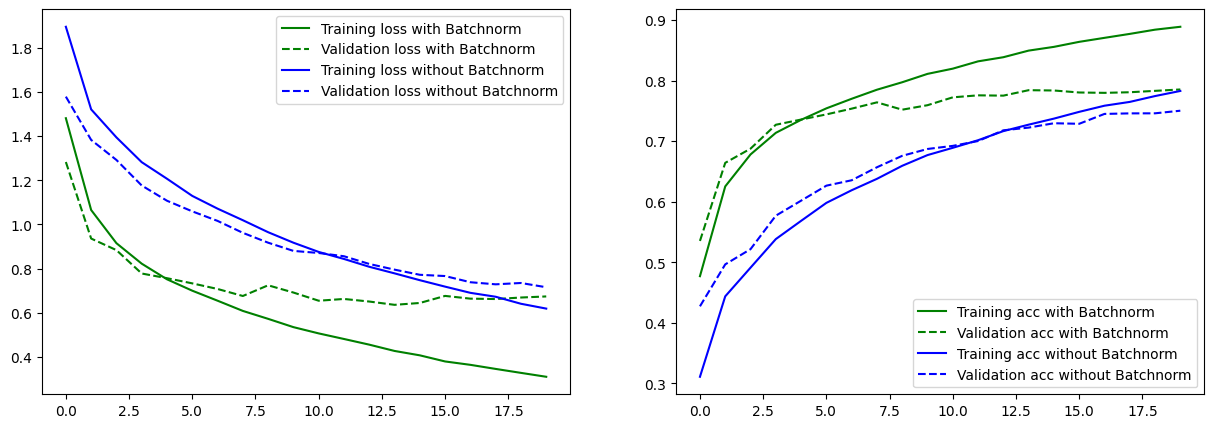

In [13]:
num_epochs = 20
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, use_batch_norm in enumerate([True, False]):
    model_dropout = CNN(use_batch_norm=use_batch_norm, use_dropout=True).to(device)

    optimizer = torch.optim.Adam(model_dropout.parameters())

    epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs = trainer(model_dropout, train_loader, test_loader, optimizer, criterion, num_epochs)

    axes[0].plot(epoch_train_losses, linestyle='-', color='g' if i == 0 else 'b', label=f'Training loss {"with" if use_batch_norm else "without"} Batchnorm')
    axes[0].plot(epoch_val_losses, linestyle='--', color='g' if i == 0 else 'b', label=f'Validation loss {"with" if use_batch_norm else "without"} Batchnorm')
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(epoch_train_accs, linestyle='-', color='g' if i == 0 else 'b', label=f'Training acc {"with" if use_batch_norm else "without"} Batchnorm')
    axes[1].plot(epoch_val_accs, linestyle='--', color='g' if i == 0 else 'b', label=f'Validation acc {"with" if use_batch_norm else "without"} Batchnorm')
    axes[1].legend()
    axes[1].grid()

plt.show()

# Plots comparing everything


Epoch 1/20
----------
Train Loss: 1.8741, Train Accuracy: 0.3189
Val Loss: 1.5762, Val Accuracy: 0.4224

Epoch 2/20
----------
Train Loss: 1.4910, Train Accuracy: 0.4598
Val Loss: 1.4027, Val Accuracy: 0.4913

Epoch 3/20
----------
Train Loss: 1.3470, Train Accuracy: 0.5145
Val Loss: 1.2992, Val Accuracy: 0.5392

Epoch 4/20
----------
Train Loss: 1.2488, Train Accuracy: 0.5515
Val Loss: 1.1830, Val Accuracy: 0.5795

Epoch 5/20
----------
Train Loss: 1.1536, Train Accuracy: 0.5878
Val Loss: 1.1017, Val Accuracy: 0.6060

Epoch 6/20
----------
Train Loss: 1.0834, Train Accuracy: 0.6155
Val Loss: 1.0670, Val Accuracy: 0.6213

Epoch 7/20
----------
Train Loss: 1.0055, Train Accuracy: 0.6414
Val Loss: 1.0237, Val Accuracy: 0.6447

Epoch 8/20
----------
Train Loss: 0.9630, Train Accuracy: 0.6593
Val Loss: 0.9669, Val Accuracy: 0.6578

Epoch 9/20
----------
Train Loss: 0.9170, Train Accuracy: 0.6756
Val Loss: 0.9569, Val Accuracy: 0.6622

Epoch 10/20
----------
Train Loss: 0.8643, Train Accur

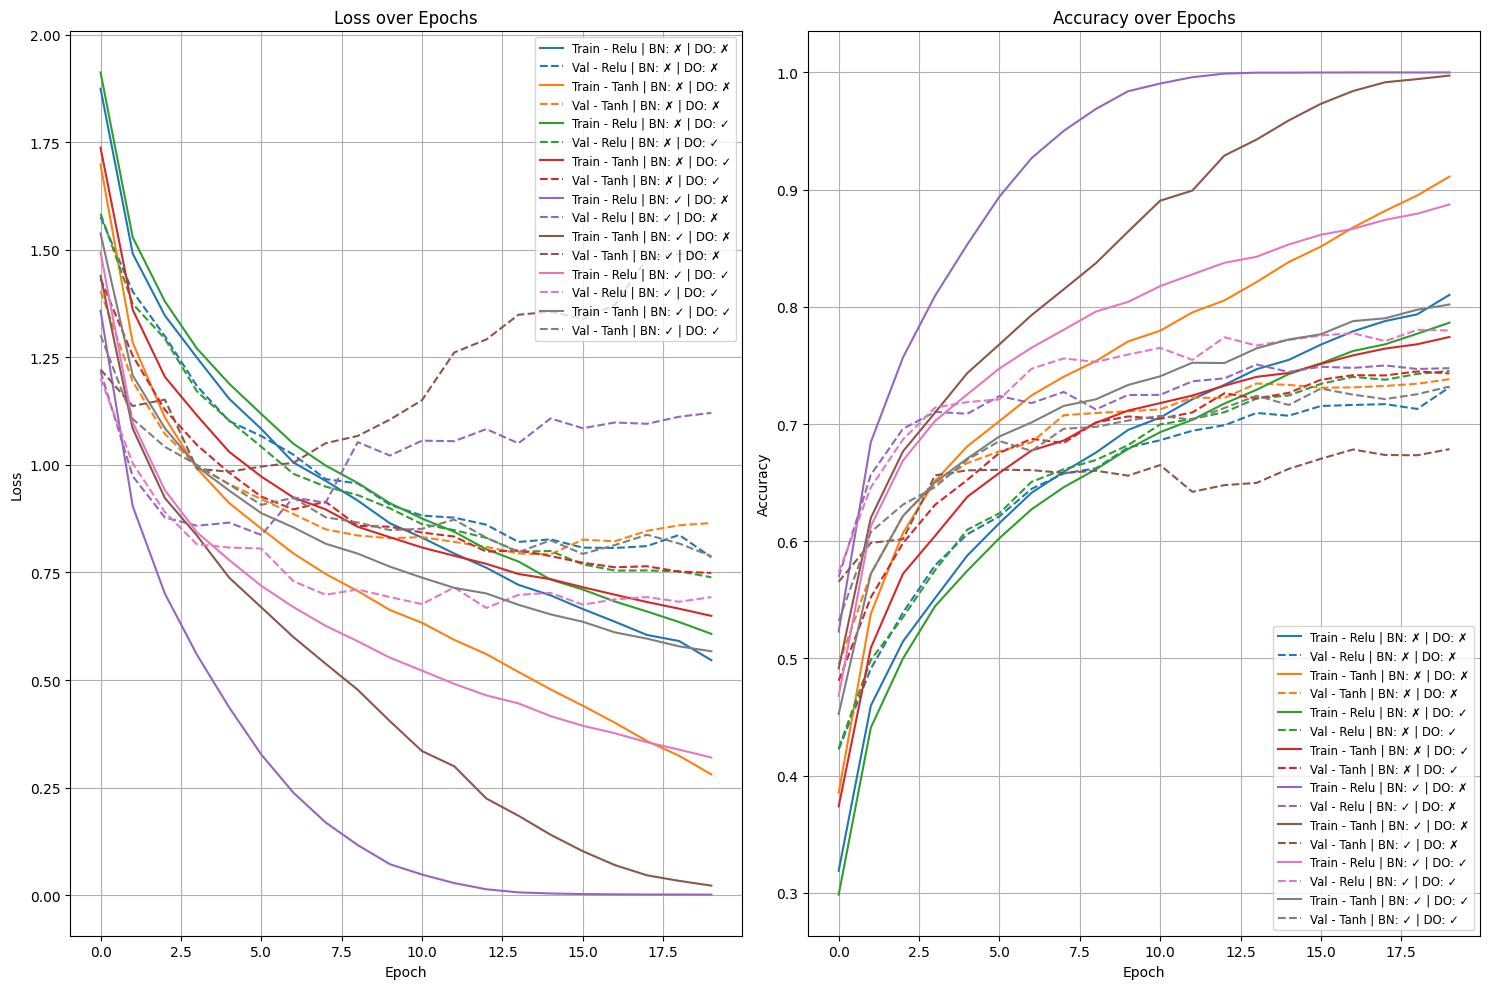

In [15]:
# Settings
batch_norm_settings = [False, True]
dropout_settings = [False, True]
activations = [F.relu, F.tanh]
num_epochs = 20
criterion = torch.nn.CrossEntropyLoss()

fig, axes = plt.subplots(1, 2, figsize=(15, 10))

colors = plt.cm.tab10.colors
combinations = list(itertools.product(batch_norm_settings, dropout_settings, activations))

for i, (use_batch_norm, use_dropout, act_func) in enumerate(combinations):
    color = colors[i]

    model = CNN(act_func, use_batch_norm, use_dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters())

    epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs = trainer(
        model, train_loader, test_loader, optimizer, criterion, num_epochs
    )

    label = f"{act_func.__name__.capitalize()} | BN: {'✓' if use_batch_norm else '✗'} | DO: {'✓' if use_dropout else '✗'}"

    axes[0].plot(epoch_train_losses, linestyle='-', color=color, label=f"Train - {label}")
    axes[0].plot(epoch_val_losses, linestyle='--', color=color, label=f"Val - {label}")

    axes[1].plot(epoch_train_accs, linestyle='-', color=color, label=f"Train - {label}")
    axes[1].plot(epoch_val_accs, linestyle='--', color=color, label=f"Val - {label}")

axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize='small', loc='upper right')
axes[0].grid()

axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize='small', loc='lower right')
axes[1].grid()

plt.tight_layout()
plt.show()

# Add Comments